In [33]:
%%bash
set -euxo pipefail
apt-get -qq update
DEBIAN_FRONTEND=noninteractive apt-get -qq install -y build-essential python3-dev
pip install -q torch torchvision triton matplotlib pandas tqdm


+ apt-get -qq update
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
+ DEBIAN_FRONTEND=noninteractive
+ apt-get -qq install -y build-essential python3-dev
+ pip install -q torch torchvision triton matplotlib pandas tqdm


In [34]:
%%bash
set -euxo pipefail
mkdir -p /content/llm-systems-optimizer/{kernels,runner,tests,assets}
touch /content/llm-systems-optimizer/__init__.py
touch /content/llm-systems-optimizer/kernels/__init__.py
touch /content/llm-systems-optimizer/runner/__init__.py
touch /content/llm-systems-optimizer/tests/__init__.py
echo " Project folders ready"


✅ Project folders ready


+ mkdir -p /content/llm-systems-optimizer/kernels /content/llm-systems-optimizer/runner /content/llm-systems-optimizer/tests /content/llm-systems-optimizer/assets
+ touch /content/llm-systems-optimizer/__init__.py
+ touch /content/llm-systems-optimizer/kernels/__init__.py
+ touch /content/llm-systems-optimizer/runner/__init__.py
+ touch /content/llm-systems-optimizer/tests/__init__.py
+ echo '✅ Project folders ready'


In [35]:
%%writefile /content/llm-systems-optimizer/kernels/rmsnorm_triton.py
import torch, triton, triton.language as tl

def rmsnorm_ref(x, w, eps=1e-5):
    norm = torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + eps)
    return (x * norm) * w

@triton.jit
def _rmsnorm_fwd(x_ptr, w_ptr, y_ptr, N, eps, BLOCK: tl.constexpr):
    pid = tl.program_id(0)
    offs = pid * N + tl.arange(0, BLOCK)
    mask = offs < (pid + 1) * N
    x = tl.load(x_ptr + offs, mask=mask, other=0.0).to(tl.float32)
    m = tl.sum(x * x) / N
    inv = 1.0 / tl.sqrt(m + eps)
    y = x * inv
    w = tl.load(w_ptr + tl.arange(0, BLOCK), mask=mask, other=1.0)
    tl.store(y_ptr + offs, (y * w).to(tl.float32), mask=mask)

def rmsnorm_triton(x, w, eps=1e-5):
    B,S,D = x.shape
    y = torch.empty_like(x)
    grid = (B*S,)
    _rmsnorm_fwd[grid](x, w, y, D, eps, BLOCK=D)
    return y


Overwriting /content/llm-systems-optimizer/kernels/rmsnorm_triton.py


In [36]:
import sys, os
ROOT = "/content/llm-systems-optimizer"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
print(" sys.path configured ->", ROOT)


✅ sys.path configured -> /content/llm-systems-optimizer


In [37]:
import torch
from kernels.rmsnorm_triton import rmsnorm_ref, rmsnorm_triton

device = "cuda" if torch.cuda.is_available() else "cpu"
B,S,D = 2,4,512
x = torch.randn(B,S,D, device=device, dtype=torch.float32)
w = torch.ones(D, device=device, dtype=torch.float32)

y_ref = rmsnorm_ref(x, w, eps=1e-5)
y_tr  = rmsnorm_triton(x, w, eps=1e-5)
print("RMSNorm max |Δ| (vs ref):", (y_ref - y_tr).abs().max().item())


RMSNorm max |Δ| (vs ref): 7.152557373046875e-07


In [38]:
import torch.nn as nn, torch

V, SEQ, D = 50257, 128, 512

class TinyBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(V, D)
        self.ln  = nn.LayerNorm(D)
        self.fc1 = nn.Linear(D, 4*D)
        self.fc2 = nn.Linear(4*D, D)
    def forward(self, x):
        x = self.emb(x)
        x = torch.relu(self.fc1(self.ln(x)))
        return self.fc2(x)


In [39]:
def make_pinned_batch(bs):
    x = torch.randint(0, V, (bs, SEQ), pin_memory=True)
    y = torch.randint(0, V, (bs, SEQ), pin_memory=True)
    return x, y

xent = nn.CrossEntropyLoss()


In [40]:
import torch, torch.nn as nn

V, SEQ, D = 50257, 128, 512  # vocab, sequence, model dim

class TinyBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(V, D)
        self.ln  = nn.LayerNorm(D)
        self.fc1 = nn.Linear(D, 4*D)
        self.fc2 = nn.Linear(4*D, D)
        self.head = nn.Linear(D, V, bias=False)  # <-- vocab head

    def forward(self, x):             # x: [B, S] (token ids)
        h = self.emb(x)               # [B, S, D]
        h = self.ln(h)                # [B, S, D]
        h = torch.relu(self.fc1(h))   # [B, S, 4D]
        h = self.fc2(h)               # [B, S, D]
        logits = self.head(h)         # [B, S, V]
        return logits

xent = nn.CrossEntropyLoss()


In [41]:
import time, torch
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_float32_matmul_precision("high")  # optional speed hint

def make_pinned_batch(bs):
    x = torch.randint(0, V, (bs, SEQ), pin_memory=True)
    y = torch.randint(0, V, (bs, SEQ), pin_memory=True)
    return x, y

model = TinyBlock().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
compiled = torch.compile(model, mode="reduce-overhead")

BS = 8
tokens, t0 = 0, time.time()
for step in range(100):
    xb, yb = make_pinned_batch(BS)
    xb = xb.to(device, non_blocking=True)
    yb = yb.to(device, non_blocking=True)

    opt.zero_grad(set_to_none=True)
    logits = compiled(xb)                  # [B,S,V]
    loss = xent(logits.view(-1, V), yb.view(-1))  # [B*S, V] vs [B*S]
    loss.backward()
    opt.step()

    tokens += BS * SEQ
    if (step+1) % 10 == 0:
        dt = time.time() - t0
        print(f"[compile] step {step+1:03d}  loss={loss.item():.3f}  toks/sec={tokens/dt:.0f}")


[compile] step 010  loss=10.847  toks/sec=1403
[compile] step 020  loss=10.861  toks/sec=2612
[compile] step 030  loss=10.835  toks/sec=3634
[compile] step 040  loss=10.837  toks/sec=4514
[compile] step 050  loss=10.850  toks/sec=5279
[compile] step 060  loss=10.839  toks/sec=5953
[compile] step 070  loss=10.834  toks/sec=6544
[compile] step 080  loss=10.831  toks/sec=7073
[compile] step 090  loss=10.841  toks/sec=7544
[compile] step 100  loss=10.832  toks/sec=7969


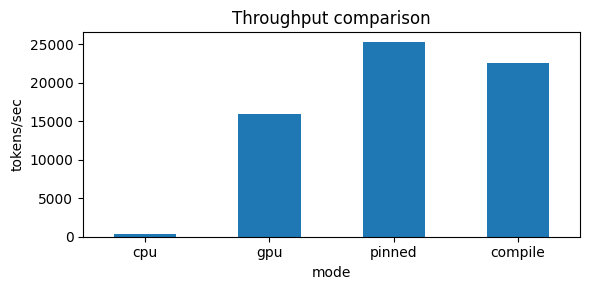

      mode  tokens_per_sec
0      cpu      297.842133
1      gpu    15987.842506
2   pinned    25285.024123
3  compile    22613.960465


In [43]:
import time, torch
import pandas as pd, matplotlib.pyplot as plt

# assumes TinyBlock, xent, V, SEQ, make_pinned_batch() already defined
# TinyBlock must return logits of shape [B, S, V]

def make_unpinned_batch(bs, seq=SEQ, vocab=V):
    x = torch.randint(0, vocab, (bs, seq), device="cpu")         # NOT pinned
    y = torch.randint(0, vocab, (bs, seq), device="cpu")
    return x, y

def bench(mode, steps=50, bs=8):
    assert mode in {"cpu","gpu","pinned","compile"}
    dev = "cpu" if mode == "cpu" else "cuda"

    model = TinyBlock().to(dev)
    if mode == "compile":
        model = torch.compile(model, mode="reduce-overhead")

    opt = torch.optim.AdamW(model.parameters(), lr=3e-4)

    toks, t0 = 0, time.time()
    for _ in range(steps):
        # choose batch src + move policy
        if mode == "cpu":
            xb, yb = make_unpinned_batch(bs)                     # stay on CPU
            x, y = xb, yb
        elif mode == "gpu":
            xb, yb = make_unpinned_batch(bs)                     # CPU unpinned
            x  = xb.to(dev)                                      # blocking copy
            y  = yb.to(dev)
        else:  # "pinned" or "compile"
            xb, yb = make_pinned_batch(bs)                       # CPU pinned
            x  = xb.to(dev, non_blocking=True)                   # async H2D
            y  = yb.to(dev, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        logits = model(x)                                        # [B,S,V]
        loss = xent(logits.view(-1, V), y.view(-1))
        loss.backward(); opt.step()

        toks += bs * SEQ

    dt = time.time() - t0
    return toks / dt  # tokens/sec

modes  = ["cpu","gpu","pinned","compile"]
speeds = [bench(m, steps=50, bs=8) for m in modes]

df = pd.DataFrame({"mode": modes, "tokens_per_sec": speeds})
ax = df.plot.bar(x="mode", y="tokens_per_sec", legend=False, rot=0, figsize=(6,3))
ax.set_title("Throughput comparison")
ax.set_ylabel("tokens/sec")
plt.tight_layout()
plt.show()
print(df)
